## fxn/utils import

In [1]:
from jax import vmap
import jax
import time
import equinox as eqx
import jax.numpy as jnp
import jax.random as jr
import jax.numpy as jnp
import jax.random as jr
from jax import vmap, jit, value_and_grad
import scipy.linalg as la
from scipy.linalg import orthogonal_procrustes


import optax
import time
import functools as ft
import matplotlib.pyplot as plt
import numpy as np
import time
from equinox_module import training_MODEL, create_FNN, save_MODEL, load_FNN

In [2]:
print("\nconfiguring backend...")
jax.config.update("jax_platform_name", "cpu")


print("backend selected:\n", jax.default_backend())
print("active devices:\n", jax.devices())
print("--------------------\n")


configuring backend...
Metal device set to: Apple M1 Pro

systemMemory: 16.00 GB
maxCacheSize: 5.33 GB

backend selected:
 cpu
active devices:
 [CpuDevice(id=0)]
--------------------



W0000 00:00:1776713687.230428 30376646 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1776713687.250107 30376646 service.cc:145] XLA service 0x11a973540 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776713687.250135 30376646 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1776713687.252266 30376646 mps_client.cc:406] Using Simple allocator.
I0000 00:00:1776713687.252278 30376646 mps_client.cc:384] XLA backend will use up to 11452858368 bytes on device 0 for SimpleAllocator.


In [3]:

def activation_fn_load(act_func):
    if act_func == 'tanh':
        activation = jnp.tanh
    if act_func == 'relu':
        activation = jax.nn.relu
    if act_func == 'swish':
        activation = jax.nn.swish
    if act_func == 'sine':
        activation = jnp.sin
    if act_func == 'cosine':
        activation = jnp.cos
    if act_func == 'gelu':
        activation = jax.nn.gelu
    return activation

class DeepONet(eqx.Module):
   trunk: eqx.nn.MLP
   branch: eqx.nn.MLP
   
   def __init__(
         self, 
         TRUNK_INPUT_DIM , TRUNK_OUTPUT_DIM , TRUNK_WIDTH , TRUNK_DEPTH , TRUNK_ACT ,
         BRANCH_INPUT_DIM, BRANCH_OUTPUT_DIM, BRANCH_WIDTH, BRANCH_DEPTH, BRANCH_ACT, 
         *, key
   ):
      key, subkey_trunk, subkey_branch = jr.split(key, num=3)
      self.trunk  = eqx.nn.MLP(in_size=TRUNK_INPUT_DIM , out_size=TRUNK_OUTPUT_DIM , width_size=TRUNK_WIDTH , depth=TRUNK_DEPTH , activation=activation_fn_load(TRUNK_ACT) , key=subkey_trunk)
      self.branch = eqx.nn.MLP(in_size=BRANCH_INPUT_DIM, out_size=BRANCH_OUTPUT_DIM, width_size=BRANCH_WIDTH, depth=BRANCH_DEPTH, activation=activation_fn_load(BRANCH_ACT), key=subkey_branch)

   def __call__(self, f, x):
      trunk  = jnp.concatenate([self.trunk(x),jnp.ones((1,))])
      branch = self.branch(f)
      return jnp.dot(trunk, branch)

def create_DeepONet(*, key, HYPER_MODEL):
    TRUNK_INPUT_DIM   = HYPER_MODEL["TRUNK"]["input_dim"]
    TRUNK_OUTPUT_DIM  = HYPER_MODEL["TRUNK"]["output_dim"]
    TRUNK_WIDTH       = HYPER_MODEL["TRUNK"]["width"]
    TRUNK_DEPTH       = HYPER_MODEL["TRUNK"]["depth"]
    TRUNK_ACT         = HYPER_MODEL["TRUNK"]["act_func"]
    BRANCH_INPUT_DIM  = HYPER_MODEL["BRANCH"]["input_dim"]
    BRANCH_OUTPUT_DIM = HYPER_MODEL["BRANCH"]["output_dim"]
    BRANCH_WIDTH      = HYPER_MODEL["BRANCH"]["width"]
    BRANCH_DEPTH      = HYPER_MODEL["BRANCH"]["depth"]
    BRANCH_ACT        = HYPER_MODEL["BRANCH"]["act_func"]
    model = DeepONet(key=key, 
                     TRUNK_INPUT_DIM=TRUNK_INPUT_DIM, 
                     TRUNK_OUTPUT_DIM=TRUNK_OUTPUT_DIM, 
                     TRUNK_WIDTH=TRUNK_WIDTH, 
                     TRUNK_DEPTH=TRUNK_DEPTH, 
                     TRUNK_ACT=TRUNK_ACT,
                     BRANCH_INPUT_DIM=BRANCH_INPUT_DIM, 
                     BRANCH_OUTPUT_DIM=BRANCH_OUTPUT_DIM, 
                     BRANCH_WIDTH=BRANCH_WIDTH, 
                     BRANCH_DEPTH=BRANCH_DEPTH, 
                     BRANCH_ACT=BRANCH_ACT)
    return model

def load_DeepONet(filename):
    with open(filename, "rb") as f:
        hyperparams = json.loads(f.readline().decode())
        model = create_DeepONet(key=jr.PRNGKey(0), HYPER_MODEL=hyperparams)
        return eqx.tree_deserialise_leaves(f, model)


def create_FNN(*, key, input_dim, output_dim, width, depth, act_func):
    activation = activation_fn_load(act_func)
    return eqx.nn.MLP(in_size=input_dim, out_size=output_dim, width_size=width, depth=depth, activation=activation, key=key)

def save_MODEL(filename, hyperparams, model):
    with open(filename, "wb") as f:
        hyperparam_str = json.dumps(hyperparams)
        f.write((hyperparam_str + "\n").encode())
        eqx.tree_serialise_leaves(f, model)

def load_FNN(filename):
    with open(filename, "rb") as f:
        hyperparams = json.loads(f.readline().decode())
        model = create_FNN(key=jr.PRNGKey(0), **hyperparams)
        return eqx.tree_deserialise_leaves(f, model)

def create_OPTIMIZER(optim_hyperparams):
    LR0   = optim_hyperparams['LEARNING_RATE_INITIAL']
    if optim_hyperparams['LEARNING_RATE_SCHEDULER'] == 'exponential':
        STEP  = optim_hyperparams['LEARNING_RATE_STEP']
        DECAY = optim_hyperparams['LEARNING_RATE_DECAY']
        LEARNING_RATE = optax.schedules.exponential_decay(LR0, STEP, DECAY)
    else:
        LEARNING_RATE = LR0
    
    OPTIM_NAME = optim_hyperparams['NAME']
    print(f'Selected Optimizer is [ {OPTIM_NAME} ], Initial Learning Rate is {LR0:1.2e}')
    if optim_hyperparams['LEARNING_RATE_SCHEDULER'] == 'exponential':
        print(f'You are using [ exponential ] learning rate scheduler with rate: {DECAY:.2f} and step: {STEP}')
    else:
        print(f'You are using [ constant ] learning rate')
            
    if OPTIM_NAME == 'adabelief':
        optimizer = optax.adabelief(LEARNING_RATE)
    if OPTIM_NAME == 'adadelta':
        optimizer = optax.adadelta(LEARNING_RATE)
    if OPTIM_NAME == 'adan':
        optimizer = optax.adan(LEARNING_RATE)
    if OPTIM_NAME == 'adafactor':
        optimizer = optax.adafactor(LEARNING_RATE)
    if OPTIM_NAME == 'adagrad':
        optimizer = optax.adagrad(LEARNING_RATE) 
    if OPTIM_NAME == 'adam':
        optimizer = optax.adam(LEARNING_RATE) 
    if OPTIM_NAME == 'adamw':
        optimizer = optax.adamw(LEARNING_RATE) 
    if OPTIM_NAME == 'adamax':
        optimizer = optax.adamax(LEARNING_RATE) 
    if OPTIM_NAME == 'adamaxw':
        optimizer = optax.adamaxw(LEARNING_RATE) 
    if OPTIM_NAME == 'amsgrad':
        optimizer = optax.amsgrad(LEARNING_RATE) 
    if OPTIM_NAME == 'lion':
        optimizer = optax.lion(LEARNING_RATE) 
    if OPTIM_NAME == 'nadam':
        optimizer = optax.nadam(LEARNING_RATE)
    if OPTIM_NAME == 'nadamw':
        optimizer = optax.nadamw(LEARNING_RATE) 
    if OPTIM_NAME == 'novograd':
        optimizer = optax.novograd(LEARNING_RATE) 
    if OPTIM_NAME == 'polyak_sgd':
        optimizer = optax.polyak_sgd(LEARNING_RATE)
    if OPTIM_NAME == 'radam':
        optimizer = optax.radam(LEARNING_RATE) 
    if OPTIM_NAME == 'rmsprop':
        optimizer = optax.rmsprop(LEARNING_RATE)
    if OPTIM_NAME == 'sgd':
        optimizer = optax.sgd(LEARNING_RATE) 
    if OPTIM_NAME == 'sm3':
        optimizer = optax.sm3(LEARNING_RATE)
    if OPTIM_NAME == 'yogi':
        optimizer = optax.yogi(LEARNING_RATE) 
         
    return optimizer


def training_MODEL(model, custom_loss_fn, HYPER_OPTIM):
  
  MAXITER     = HYPER_OPTIM['MAXITER']
  PRINT_EVERY = HYPER_OPTIM['PRINT_EVERY']
  optimizer  = create_OPTIMIZER(HYPER_OPTIM)
  opt_state  = optimizer.init(eqx.filter(model, eqx.is_inexact_array))

  @eqx.filter_value_and_grad
  def loss_fn(model):
    return custom_loss_fn(model)

  @eqx.filter_jit
  def make_step(model, opt_state):
    lvalue, grads = loss_fn(model)
    updates, opt_state = optimizer.update(grads, opt_state, model)
    model = eqx.apply_updates(model, updates)
    return lvalue, model, opt_state

  log_loss  = []
  log_minloss = []
  print(25*'-' + 'TRAINING STARTS' + 25*'-')
  print(65*'-')
  start_time = time.time()
  for epoch in range(MAXITER):
      current_loss, model, opt_state = make_step(model, opt_state)
      log_loss.append(current_loss)
      if epoch == 0:
          log_minloss.append(current_loss)
          model_opt = model
      else:
          if current_loss < log_minloss[-1]:
            minloss = current_loss
            model_opt = model
          else:
            minloss = log_minloss[-1]
          log_minloss.append(minloss)
          
      if (epoch == 0) or (epoch % PRINT_EVERY == 0):
          end_time = time.time()
          if PRINT_EVERY >= 1000:
            print(f"Epoch {epoch//1000:3d}K: loss = {current_loss:.4e}, minloss = {log_minloss[-1]:.4e}, Time: {end_time-start_time:.2f}s")
          else:
            print(f"Epoch {epoch:4d}: loss = {current_loss:.4e}, minloss = {log_minloss[-1]:.4e}, Time: {end_time-start_time:.2f}s")
          start_time = time.time()

  current_loss, _ = loss_fn(model)
  log_loss.append(current_loss)        
  if current_loss < log_minloss[-1]:
    minloss = current_loss
    model_opt = model
  else:
    minloss = log_minloss[-1]
  log_minloss.append(minloss)
  end_time = time.time()
  if PRINT_EVERY >= 1000:
    print(f"Epoch {MAXITER//1000:3d}K: loss = {current_loss:.4e}, minloss = {log_minloss[-1]:.4e}, Time: {end_time-start_time:.2f}s")
  else:
    print(f"Epoch {MAXITER:4d}: loss = {current_loss:.4e}, minloss = {log_minloss[-1]:.4e}, Time: {end_time-start_time:.2f}s")
  
  
  if HYPER_OPTIM['LBFGS']['USE'] == 'on':
      params, static = eqx.partition(model_opt, eqx.is_array)
      optim = optax.lbfgs()
      opt_state = optim.init(params)
    
      @eqx.filter_jit
      def loss_fn_LBFGS(params):
        model = eqx.combine(params, static)
        return custom_loss_fn(model)

      @eqx.filter_jit
      def make_step_bfgs(params, opt_state):
        loss, grads = eqx.filter_value_and_grad(loss_fn_LBFGS)(params)

        updates, opt_state = optim.update(
                grads, 
                opt_state,
                params,
                value=loss,
                grad=grads,
                value_fn=loss_fn_LBFGS
            )

        params = eqx.apply_updates(params, updates)
        return loss, params, opt_state
    
      # Training Loop 
      MAXITER     = HYPER_OPTIM['LBFGS']['MAXITER']
      PRINT_EVERY = HYPER_OPTIM['LBFGS']['PRINT_EVERY']
      print(65*'-')
      print(21*'-' + '[LBFGS] TRAINING STARTS' + 21*'-')
      print(25*'-' + f' MAXITER= {MAXITER} ' + 25*'-')
      start_time  = time.time()
      for epoch in range(MAXITER):
        model = eqx.combine(params, static)
        current_loss, params, opt_state = make_step_bfgs(params, opt_state)
        log_loss.append(current_loss)
        if epoch == 0:
          log_minloss.append(current_loss)
          model_opt = model
        else:
          if current_loss < log_minloss[-1]:
            minloss = current_loss
            model_opt = model
          else:
            minloss = log_minloss[-1]
          log_minloss.append(minloss)
          
        if (epoch == 0) or (epoch % PRINT_EVERY == 0):
          end_time = time.time()
          if PRINT_EVERY >= 1000:
             print(f"[LBFGS] Ep {epoch//1000:3d}K: loss = {current_loss:.2e}, minloss = {log_minloss[-1]:.2e}, Time: {end_time-start_time:.2f}s")
          else:
             print(f"[LBFGS] Ep {epoch:3d}: loss = {current_loss:.2e}, minloss = {log_minloss[-1]:.2e}, Time: {end_time-start_time:.2f}s")
          start_time = time.time()
          
      model = eqx.combine(params, static)
      current_loss, _ = loss_fn(model)
      log_loss.append(current_loss)        
      if current_loss < log_minloss[-1]:
          minloss = current_loss
          model_opt = model
      else:
          minloss = log_minloss[-1]
          log_minloss.append(minloss)
      end_time = time.time()
      if PRINT_EVERY >= 1000:
          print(f"[LBFGS] Ep {MAXITER//1000:3d}K: loss = {current_loss:.2e}, minloss = {log_minloss[-1]:.2e}, Time: {end_time-start_time:.2f}s")
      else:
          print(f"[LBFGS] Ep{MAXITER:3d}: loss = {current_loss:.2e}, minloss = {log_minloss[-1]:.2e}, Time: {end_time-start_time:.2f}s")
    
  return model_opt, log_loss, log_minloss



def training_MODEL_RBA(model, custom_loss_fn, custom_loss_fn_LBFGS, HYPER_OPTIM, HYPER_RBA):
  
  MAXITER     = HYPER_OPTIM['MAXITER']
  PRINT_EVERY = HYPER_OPTIM['PRINT_EVERY']
  optimizer  = create_OPTIMIZER(HYPER_OPTIM)
  opt_state  = optimizer.init(eqx.filter(model, eqx.is_inexact_array))

  RBA_lambda = HYPER_RBA['RBA_lambda']
  
#   @eqx.filter_value_and_grad
  @eqx.filter_jit
  def loss_fn(model,RBA_lambda):
    return custom_loss_fn(model,RBA_lambda)

  @eqx.filter_jit
  def make_step(model, opt_state, RBA_lambda):
    loss_fn_RBA = ft.partial(loss_fn, RBA_lambda=RBA_lambda)
    (_, (RBA_lambda,lvalue)), grads = eqx.filter_value_and_grad(loss_fn_RBA, has_aux=True)(model)
    updates, opt_state = optimizer.update(grads, opt_state, model)
    model = eqx.apply_updates(model, updates)
    return lvalue, model, opt_state, RBA_lambda

  log_loss  = []
  log_minloss = []
  print(25*'-' + 'TRAINING STARTS' + 25*'-')
  print(65*'-')
  start_time = time.time()
  for epoch in range(MAXITER):
      current_loss, model, opt_state, RBA_lambda = make_step(model, opt_state, RBA_lambda)
      log_loss.append(current_loss)
      if epoch == 0:
          log_minloss.append(current_loss)
          model_opt = model
      else:
          if current_loss < log_minloss[-1]:
            minloss = current_loss
            model_opt = model
          else:
            minloss = log_minloss[-1]
          log_minloss.append(minloss)
          
      if (epoch == 0) or (epoch % PRINT_EVERY == 0):
          end_time = time.time()
          if PRINT_EVERY >= 1000:
            print(f"Epoch {epoch//1000:3d}K: loss = {current_loss:.4e}, minloss = {log_minloss[-1]:.4e}, Time: {end_time-start_time:.2f}s")
          else:
            print(f"Epoch {epoch:4d}: loss = {current_loss:.4e}, minloss = {log_minloss[-1]:.4e}, Time: {end_time-start_time:.2f}s")
          start_time = time.time()

  current_loss = loss_fn(model,RBA_lambda)[1][1]
  log_loss.append(current_loss)        
  if current_loss < log_minloss[-1]:
    minloss = current_loss
    model_opt = model
  else:
    minloss = log_minloss[-1]
  log_minloss.append(minloss)
  end_time = time.time()
  if PRINT_EVERY >= 1000:
    print(f"Epoch {MAXITER//1000:3d}K: loss = {current_loss:.4e}, minloss = {log_minloss[-1]:.4e}, Time: {end_time-start_time:.2f}s")
  else:
    print(f"Epoch {MAXITER:4d}: loss = {current_loss:.4e}, minloss = {log_minloss[-1]:.4e}, Time: {end_time-start_time:.2f}s")
  
  
  if HYPER_OPTIM['LBFGS']['USE'] == 'on':
      params, static = eqx.partition(model_opt, eqx.is_array)
      optim = optax.lbfgs()
      opt_state = optim.init(params)
    
      @eqx.filter_jit
      def loss_fn_LBFGS(params):
        model = eqx.combine(params, static)
        return ft.partial(custom_loss_fn_LBFGS, RBA_lambda=RBA_lambda)(model)

      @eqx.filter_jit
      def make_step_bfgs(params, opt_state):
        loss, grads = eqx.filter_value_and_grad(loss_fn_LBFGS)(params)

        updates, opt_state = optim.update(
                grads, 
                opt_state,
                params,
                value=loss,
                grad=grads,
                value_fn=loss_fn_LBFGS
            )

        params = eqx.apply_updates(params, updates)
        return loss, params, opt_state
    
      # Training Loop 
      MAXITER     = HYPER_OPTIM['LBFGS']['MAXITER']
      PRINT_EVERY = HYPER_OPTIM['LBFGS']['PRINT_EVERY']
      print(65*'-')
      print(21*'-' + '[LBFGS] TRAINING STARTS' + 21*'-')
      print(25*'-' + f' MAXITER= {MAXITER} ' + 25*'-')
      start_time  = time.time()
      for epoch in range(MAXITER):
        model = eqx.combine(params, static)
        current_loss, params, opt_state = make_step_bfgs(params, opt_state)
        log_loss.append(current_loss)
        if epoch == 0:
          log_minloss.append(current_loss)
          model_opt = model
        else:
          if current_loss < log_minloss[-1]:
            minloss = current_loss
            model_opt = model
          else:
            minloss = log_minloss[-1]
          log_minloss.append(minloss)
          
        if (epoch == 0) or (epoch % PRINT_EVERY == 0):
          end_time = time.time()
          if PRINT_EVERY >= 1000:
             print(f"[LBFGS] Ep {epoch//1000:3d}K: loss = {loss_fn(model,RBA_lambda)[1][1]:.2e}, minloss = {log_minloss[-1]:.2e}, Time: {end_time-start_time:.2f}s")
          else:
             print(f"[LBFGS] Ep {epoch:3d}: loss = {loss_fn(model,RBA_lambda)[1][1]:.2e}, minloss = {log_minloss[-1]:.2e}, Time: {end_time-start_time:.2f}s")
          start_time = time.time()
          
      model = eqx.combine(params, static)
      current_loss = loss_fn(model,RBA_lambda)[1][1]
      log_loss.append(current_loss)        
      if current_loss < log_minloss[-1]:
          minloss = current_loss
          model_opt = model
      else:
          minloss = log_minloss[-1]
          log_minloss.append(minloss)
      end_time = time.time()
      if PRINT_EVERY >= 1000:
          print(f"[LBFGS] Ep {MAXITER//1000:3d}K: loss = {loss_fn(model,RBA_lambda)[1][1]:.2e}, minloss = {log_minloss[-1]:.2e}, Time: {end_time-start_time:.2f}s")
      else:
          print(f"[LBFGS] Ep{MAXITER:3d}: loss = {loss_fn(model,RBA_lambda)[1][1]:.2e}, minloss = {log_minloss[-1]:.2e}, Time: {end_time-start_time:.2f}s")
    
  return model_opt, log_loss, log_minloss

## load data

In [4]:
test_data = jnp.load("hw4_burgers_train_data.npz")
train_data = jnp.load("hw4_burgers_train_data.npz")

test_xt, test_u, test_params = test_data["xt_grid"], test_data["u_sol"], test_data["params"]
train_xt, train_u, train_params = train_data["xt_grid"], train_data["u_sol"], train_data["params"]

x_grid = jnp.unique(train_xt[:, 0])
t_grid = jnp.unique(train_xt[:, 1])

## deeponet definition


In [5]:
SEED = 77

# per assignment
BRANCH_INPUT_DIM  = 3 ## NOW INCLUDES TIME
BRANCH_WIDTH      = 100
BRANCH_DEPTH      = 4
BRANCH_ACTIVATION = 'tanh'

TRUNK_INPUT_DIM   = 2
TRUNK_WIDTH       = 16
TRUNK_DEPTH       = 4
TRUNK_ACTIVATION  = 'gelu'

DEEPONET_WIDTH    = 4
# sine, cosine, relu, tanh, gelu, swish


LEARNING_RATE = 1e-3
OPTIMIZER_NAME = 'adam'
# adabelief, adadelta, adan, adafactor, adagrad, adam, adamw,
# adamax, adamaxw, amsgrad, lion, nadam, nadamw, novograd, radam,
# rmsprop, sgd, sm3, yogi, polyak_sgd
MAXITER = 40_000
PRINT_EVERY = 1_000

LR_SCHEDULER = 'exponential' #'constant' # exponential or constant
LR_DECAY = 0.95
LR_STEP  = 3000

LBFGS_USE = 'off'
LBFGS_MAXITER = 10_000
LBFGS_PRINT_EVERY = 1_000
if LBFGS_USE != 'on':
    LBFGS_MAXITER = 0
    LBFGS_PRINT_EVERY = 0

In [6]:
HYPER_MODEL = {"TRUNK": {"input_dim": TRUNK_INPUT_DIM, 
               "output_dim": DEEPONET_WIDTH, 
               "width": TRUNK_WIDTH,
               "depth": TRUNK_DEPTH-1, 
               "act_func": TRUNK_ACTIVATION},
               "BRANCH": {"input_dim": BRANCH_INPUT_DIM, 
               "output_dim": DEEPONET_WIDTH+1, 
               "width": BRANCH_WIDTH,
               "depth": BRANCH_DEPTH-1, 
               "act_func": BRANCH_ACTIVATION}
            }

HYPER_OPTIM = {"MAXITER": MAXITER, 
               "NAME": OPTIMIZER_NAME, 
               "LEARNING_RATE_SCHEDULER": LR_SCHEDULER, 
               "LEARNING_RATE_INITIAL": LEARNING_RATE, 
               "LEARNING_RATE_DECAY": LR_DECAY, 
               "LEARNING_RATE_STEP": LR_STEP, 
               "PRINT_EVERY": PRINT_EVERY,
               "LBFGS": {"USE": LBFGS_USE, "MAXITER": LBFGS_MAXITER, "PRINT_EVERY": LBFGS_PRINT_EVERY}
               }

In [7]:
key = jr.PRNGKey(SEED)
key, subkey_model_trunk, subkey_model_A, subkey_model_branch, subkey_w, subkey_w_test = jr.split(key, num=6)

In [8]:
model_trunk = create_FNN(key=subkey_model_trunk, **HYPER_MODEL["TRUNK"])

In [9]:
model_A = jnp.zeros((len(t_grid), DEEPONET_WIDTH, train_u.shape[0]))  # (T, K, N)
print(model_A.shape)
model       = model_trunk, model_A

(201, 4, 25)


## loss fn and training

### trunk network

In [10]:
def loss_fn(model):
    model_trunk, model_A = model
    trunk_out_flat = vmap(lambda x: model_trunk(x))(train_xt) # (T*X, K)
    #trunk_out = trunk_out_flat.reshape(len(t_grid), len(x_grid), -1)  # (T, X, K)

    trunk_out = trunk_out_flat.reshape(len(x_grid), len(t_grid), -1).transpose(1, 0, 2)  # (T, X, K)


    model_out = jnp.einsum("txk, tkn -> txn", trunk_out, model_A)
    #u_train_flat = train_u.T.reshape(len(t_grid), len(x_grid), -1)
    u_train_flat = train_u.T.reshape(len(x_grid), len(t_grid), -1).transpose(1, 0, 2)  # (T, X, N)
    residual = model_out - u_train_flat

    return jnp.mean(residual**2)

In [11]:
start_time = time.time()
model, log_loss, log_minloss = training_MODEL(model, loss_fn, HYPER_OPTIM)
end_time = time.time()

Selected Optimizer is [ adam ], Initial Learning Rate is 1.00e-03
You are using [ exponential ] learning rate scheduler with rate: 0.95 and step: 3000
-------------------------TRAINING STARTS-------------------------
-----------------------------------------------------------------
Epoch   0K: loss = 1.5688e-01, minloss = 1.5688e-01, Time: 0.34s
Epoch   1K: loss = 1.2839e-04, minloss = 1.2839e-04, Time: 6.48s
Epoch   2K: loss = 4.2861e-05, minloss = 4.2861e-05, Time: 6.51s
Epoch   3K: loss = 1.6913e-05, minloss = 1.6913e-05, Time: 6.46s
Epoch   4K: loss = 9.8120e-06, minloss = 9.8120e-06, Time: 6.48s
Epoch   5K: loss = 4.1305e-06, minloss = 4.1305e-06, Time: 6.52s
Epoch   6K: loss = 2.2224e-06, minloss = 2.2224e-06, Time: 6.42s
Epoch   7K: loss = 1.6832e-06, minloss = 1.6832e-06, Time: 6.40s
Epoch   8K: loss = 1.4295e-06, minloss = 1.4295e-06, Time: 6.43s
Epoch   9K: loss = 1.2776e-06, minloss = 1.2776e-06, Time: 6.35s
Epoch  10K: loss = 1.2094e-06, minloss = 1.1781e-06, Time: 6.35s
Ep

In [12]:
T_MAT = jnp.concatenate([vmap(lambda x: model_trunk(x))(train_xt), jnp.ones([train_xt.shape[0],1])], axis=1)
print(T_MAT.shape)  # should be (T*X, K+1)

T_MAT_3d = T_MAT.reshape(len(t_grid), len(x_grid), -1)  # (T, X, K+1)
print(T_MAT_3d.shape)  # should be (T, X, K+1)

(40401, 5)
(201, 201, 5)


In [13]:
print(train_xt[:3])  # should show same t, varying x

[[-3.    0.  ]
 [-2.97  0.  ]
 [-2.94  0.  ]]


In [14]:
# T_MAT_3d = T_MAT.reshape(len(t_grid), len(x_grid), -1)  # (X, T, K+1)

# ## ADDING
# T_MAT_3d = T_MAT_3d.transpose(1, 0, 2)  # (T, X, K+1)

# data is X major
T_MAT_3d = T_MAT.reshape(len(x_grid), len(t_grid), -1).transpose(1, 0, 2)  # (T, X, K+1)

#U_3d = np.array(train_u).reshape(train_u.shape[0], len(t_grid), len(x_grid)).transpose(1, 2, 0)  # (T, X, N)

U_3d = np.array(train_u).reshape(train_u.shape[0], len(x_grid), len(t_grid)).transpose(2, 1, 0)  # (T, X, N)

Q_ref, _ = la.qr(np.mean(T_MAT_3d, axis=1), mode='economic')  # (X, K+1)

Q_sign = None
R_sign = None


LOOKBACK = 5  # number of previous frames to average

# for i in range(len(t_grid)):
#     Q, R = la.qr(np.array(T_MAT_3d[i, :, :]), mode='economic')
    
#     if i == 0:
#         Q_sign = Q[np.newaxis]
#         R_sign = R[np.newaxis]
#     else:
#         # average over last LOOKBACK frames as reference
#         start = max(0, i - LOOKBACK)
#         Q_ref = np.mean(Q_sign[start:i], axis=0)  # (X, K+1)
        
#         for j in range(Q.shape[1]):
#             overlap = np.dot(Q_ref[:, j], Q[:, j])
#             sign = np.sign(overlap) if np.abs(overlap) > 1e-10 else 1.0
#             Q[:, j] *= sign
#             R[j, :] *= sign
        
#         Q_sign = np.concatenate([Q_sign, Q[np.newaxis]], axis=0)
#         R_sign = np.concatenate([R_sign, R[np.newaxis]], axis=0)



for i in range(len(t_grid)):
    Q, R = la.qr(np.array(T_MAT_3d[i, :, :]), mode='economic')  # QR of (X, K+1)
    
    if i == 0:
        Q_sign = Q[np.newaxis]
        R_sign = R[np.newaxis]
    else:
        for j in range(Q.shape[1]):
            overlap = np.dot(Q_sign[-1, :, j], Q[:, j])
            sign = np.sign(overlap) if np.abs(overlap) > 1e-10 else 1.0
            Q[:, j] *= sign
            R[j, :] *= sign
        Q_sign = np.concatenate([Q_sign, Q[np.newaxis]], axis=0)
        R_sign = np.concatenate([R_sign, R[np.newaxis]], axis=0)


R_procs = [None] * len(t_grid)
Q_smooth = Q_sign.copy()
for i in range(1, len(t_grid)):
    R_proc, _ = orthogonal_procrustes(Q_smooth[i], Q_smooth[i-1])
    Q_smooth[i] = Q_smooth[i] @ R_proc
    R_procs[i] = R_proc

R_smooth = R_sign.copy()
R_smooth[0] = R_sign[0]
for i in range(1, len(t_grid)):
    R_smooth[i] = R_procs[i].T @ R_sign[i]


In [15]:
# lsq_A per time step: solve T_MAT_3d[t] @ A[t] = U_true for each t

#RA_target = np.zeros((len(t_grid), Q_sign.shape[2], train_u.shape[0]))
RA_target = np.random.randn(len(t_grid), Q_sign.shape[2], train_u.shape[0]) * 1e-3
for i in range(len(t_grid)):
    A_t = la.lstsq(np.array(T_MAT_3d[i, :, :]), U_3d[i])[0]
    RA_target[i] = R_smooth[i] @ A_t

RA_target = jnp.array(RA_target)
RA_scale = np.std(np.array(RA_target), axis=(0, 2), keepdims=True) + 1e-8  # (1, K+1, 1)

In [16]:
# reconstruct: Q_sign (T, X, K+1) @ R_sign (T, K+1, K+1) @ A_t should give U_3d
recon = np.einsum("txk,tkj->txj", Q_sign, R_sign) 
T_MAT_check = T_MAT_3d  # (T, X, K+1)
print("QR reconstruction error:", np.max(np.abs(recon - T_MAT_check)))

# also check that Q_sign @ R_sign @ A recovers U
A_check = np.zeros((len(t_grid), Q_sign.shape[2], train_u.shape[0]))
for i in range(len(t_grid)):
    A_check[i] = la.lstsq(np.array(T_MAT_3d[i, :, :]), U_3d[i])[0]

recon_U = np.einsum("txk,tkn->txn", Q_sign, R_sign @ A_check if False else 
                    np.array([R_sign[i] @ A_check[i] for i in range(len(t_grid))]))
print("U reconstruction error:", np.max(np.abs(recon_U - U_3d)))

QR reconstruction error: 1.8239021e-05
U reconstruction error: 0.19546078158370084


In [17]:
# check lstsq residual at a single time step
i = 0
A_t = la.lstsq(np.array(T_MAT_3d[i, :, :]), U_3d[i])[0]  # (K+1, N)
recon_slice = T_MAT_3d[i, :, :] @ A_t  # (X, N)
print("lstsq residual at t=0:", np.max(np.abs(recon_slice - U_3d[i])))

# check that R @ A recovers Q^T @ U
QTA = Q_sign[i].T @ U_3d[i]  # (K+1, N)
RA  = R_sign[i] @ A_t         # (K+1, N)
print("RA vs Q^T U error:", np.max(np.abs(RA - QTA)))

lstsq residual at t=0: 2.3189932e-07
RA vs Q^T U error: 1.9066839690440318e-08


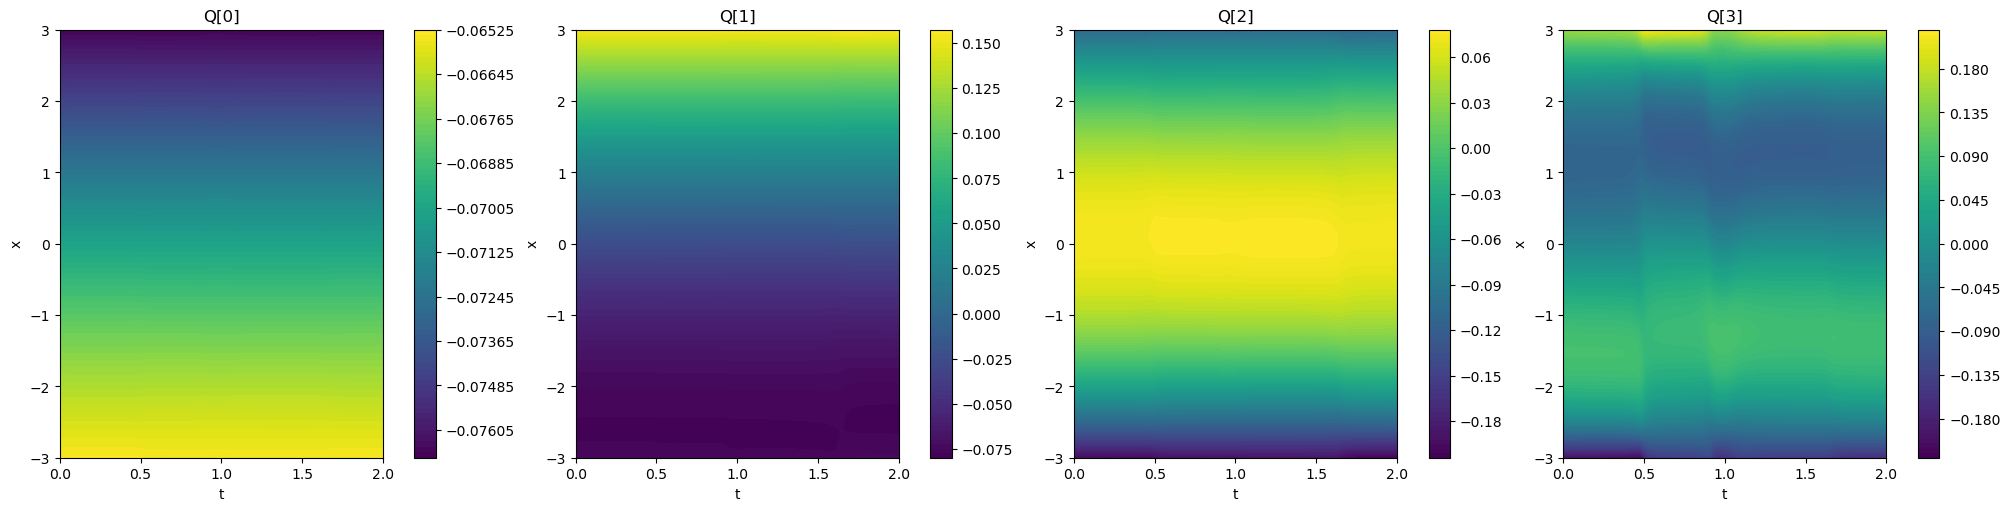

In [18]:
num_bases = 4
ncols = 4
nrows = int(np.ceil(num_bases / ncols))
T, X  = np.meshgrid(t_grid, x_grid, indexing="ij")

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows), constrained_layout=True)
axes = axes.flatten()

for k, ax in enumerate(axes):
    if k < num_bases:
        Q_k = Q_smooth[:, :, k]
        im  = ax.contourf(T, X, Q_k, levels=100, cmap='viridis')
        ax.set_title(f"Q[{k}]")
        ax.set_xlabel("t")
        ax.set_ylabel("x")
        fig.colorbar(im, ax=ax)
    else:
        ax.axis("off")

### branch network

In [19]:
model_branch= create_FNN(key=subkey_model_branch, **HYPER_MODEL["BRANCH"])

LEARNING_RATE = 1e-3
OPTIMIZER_NAME = 'adam'
# adabelief, adadelta, adan, adafactor, adagrad, adam, adamw,
# adamax, adamaxw, amsgrad, lion, nadam, nadamw, novograd, radam,
# rmsprop, sgd, sm3, yogi, polyak_sgd
MAXITER = 200_000
PRINT_EVERY = 10_000

LR_SCHEDULER = 'exponential' # exponential or constant
LR_DECAY = 0.95
LR_STEP  = 15_000

LBFGS_USE = 'off'
LBFGS_MAXITER = 10_000
LBFGS_PRINT_EVERY = 1_00
if LBFGS_USE != 'on':
    LBFGS_MAXITER = 0
    LBFGS_PRINT_EVERY = 0
    
HYPER_OPTIM_Branch = {"MAXITER": MAXITER, 
               "NAME": OPTIMIZER_NAME, 
               "LEARNING_RATE_SCHEDULER": LR_SCHEDULER, 
               "LEARNING_RATE_INITIAL": LEARNING_RATE, 
               "LEARNING_RATE_DECAY": LR_DECAY, 
               "LEARNING_RATE_STEP": LR_STEP, 
               "PRINT_EVERY": PRINT_EVERY,
               "LBFGS": {"USE": LBFGS_USE, "MAXITER": LBFGS_MAXITER, "PRINT_EVERY": LBFGS_PRINT_EVERY}
               }


In [20]:
# scaling RA

RA_scale = np.std(RA_target, axis=(0, 2), keepdims=True) + 1e-8  # (1, K+1, 1)
RA_target_normed = RA_target / RA_scale


# updating branch_loss_fn

RA_target_jnp = jnp.array(RA_target_normed)
#RA_target_jnp = jnp.array(RA_target)

# weight inversely proportional to t, emphasizing early times
t_weights = 1.0 / (jnp.array(t_grid) + t_grid[1])  # avoid div by zero at t=0
t_weights = t_weights / t_weights.mean()  # normalize so overall scale is preserved

def branch_loss_fn(model):
    B_tnK = vmap(
        lambda t_val: vmap(
            lambda u: model(jnp.concatenate([u, jnp.array([t_val])]))
        )(train_params)
    )(t_grid)
    B_MAT = jnp.swapaxes(B_tnK, 1, 2)  # (T, K+1, N)
    residual = (B_MAT - RA_target_jnp) ** 2  # (T, K+1, N)
    return jnp.mean(residual * t_weights[:, None, None])

In [21]:
# def branch_loss_fn(model):
#     B_tnK = vmap(
#         lambda t_val: vmap(
#             lambda u: model(jnp.concatenate([u, jnp.array([t_val])]))
#         )(train_params)
#     )(t_grid)                          # (T, N, K+1)
#     B_MAT = jnp.swapaxes(B_tnK, 1, 2) # (T, K+1, N)
#     return jnp.mean((B_MAT - RA_target) ** 2)

start_time = time.time()
model_branch, log_loss_branch, log_minloss_branch = training_MODEL(model_branch, branch_loss_fn, HYPER_OPTIM_Branch)
end_time = time.time()

Selected Optimizer is [ adam ], Initial Learning Rate is 1.00e-03
You are using [ exponential ] learning rate scheduler with rate: 0.95 and step: 15000
-------------------------TRAINING STARTS-------------------------
-----------------------------------------------------------------
Epoch   0K: loss = 3.6011e-01, minloss = 3.6011e-01, Time: 0.17s
Epoch  10K: loss = 2.5732e-05, minloss = 2.5053e-05, Time: 51.42s
Epoch  20K: loss = 1.1445e-05, minloss = 9.1013e-06, Time: 51.35s
Epoch  30K: loss = 1.1390e-05, minloss = 5.5968e-06, Time: 51.33s
Epoch  40K: loss = 4.4466e-06, minloss = 4.2151e-06, Time: 51.75s
Epoch  50K: loss = 2.8092e-05, minloss = 3.5002e-06, Time: 50.40s
Epoch  60K: loss = 2.0290e-04, minloss = 2.8982e-06, Time: 50.57s
Epoch  70K: loss = 2.6936e-06, minloss = 2.5390e-06, Time: 49.76s
Epoch  80K: loss = 3.1162e-06, minloss = 2.2450e-06, Time: 49.53s
Epoch  90K: loss = 2.5934e-06, minloss = 2.0170e-06, Time: 50.53s
Epoch 100K: loss = 2.4809e-06, minloss = 1.8501e-06, Time

In [22]:
for i in np.arange(0, len(t_grid)//2, -1):
    A_t = la.lstsq(np.array(T_MAT_3d[i, :, :]), U_3d[i])[0]
    res = np.max(np.abs(T_MAT_3d[i] @ A_t - U_3d[i]))
    print(f"t={i} lstsq residual: {res:.4e}")

In [23]:
print("RA_target std per t, k=0:", np.std(RA_target[:, 0, :], axis=1))
print("RA_target mean abs per t, k=0:", np.mean(np.abs(RA_target[:, 0, :]), axis=1))

RA_target std per t, k=0: [0.02857448 0.02882656 0.03101507 0.03336207 0.03583871 0.03844726
 0.04118959 0.04406713 0.04708068 0.05023055 0.05351641 0.05693724
 0.06049141 0.06417655 0.06798963 0.07192678 0.07598367 0.08015494
 0.08443477 0.08881656 0.093293   0.09785618 0.10249796 0.10720883
 0.11197992 0.11680124 0.1216623  0.12655292 0.1314622  0.13637938
 0.14129369 0.146194   0.15106967 0.15590972 0.16070405 0.16544169
 0.1701131  0.17470911 0.17922017 0.18363896 0.18795398 0.19216156
 0.1962481  0.2002238  0.20405695 0.20777239 0.21134901 0.21476693
 0.21805906 0.22120403 0.22419655 0.22705032 0.22973917 0.23230365
 0.23471436 0.23696996 0.23910528 0.24109863 0.2429499  0.24468261
 0.24631132 0.24781154 0.24919263 0.25049788 0.25171596 0.25284094
 0.25389576 0.25488123 0.25582436 0.25672176 0.25758967 0.25843465
 0.2592739  0.26011413 0.26096946 0.26184815 0.2627629  0.26373157
 0.26474875 0.26583827 0.26701304 0.26825458 0.26962453 0.27107596
 0.27264145 0.27432436 0.2761434  0.

In [24]:
print("RA_target mean:", np.mean(np.abs(RA_target)))
print("RA_target max:", np.max(np.abs(RA_target)))
print("RA_target std per k:", np.std(RA_target, axis=(0,2)))  # variation across k modes

RA_target mean: 1.0547988
RA_target max: 10.436354
RA_target std per k: [3.5773773  1.0099082  0.3820366  0.15005192 0.04500182]


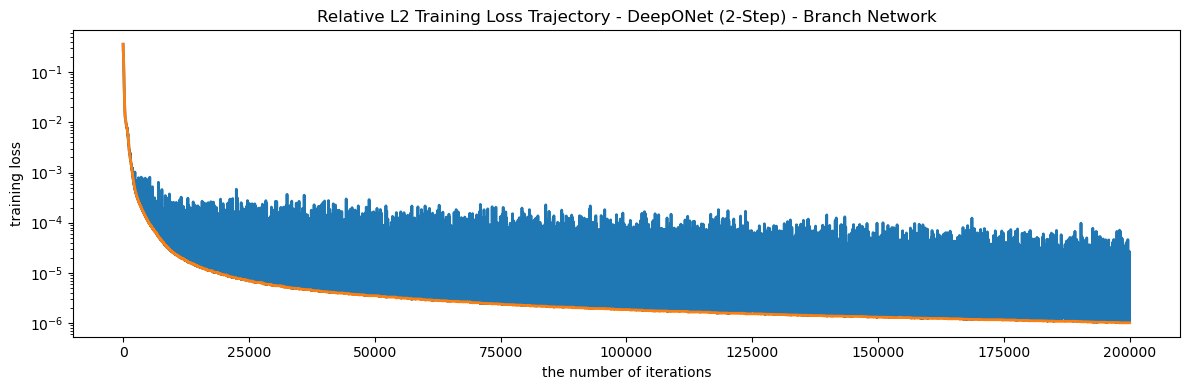

In [25]:

# print(NN_pred_final.shape)
# rel_l2_error = jnp.sqrt(jnp.sum((test_u - NN_pred_final)**2,axis=1) / jnp.sum(test_u**2,axis=1))
# print(f"Avg. Relative L2 error     : {jnp.mean(rel_l2_error):.4e}")



plt.figure(figsize = (12,4))
plt.semilogy(log_loss_branch, linewidth = 2)
plt.semilogy(log_minloss_branch, linewidth =2)
plt.xlabel('the number of iterations')
plt.ylabel('training loss')
plt.title("Relative L2 Training Loss Trajectory - DeepONet (2-Step) - Branch Network")
plt.tight_layout()
# plt.suptitle(title_str + '\n')
plt.savefig("deeponet_2step_training_branch.png")
plt.show()

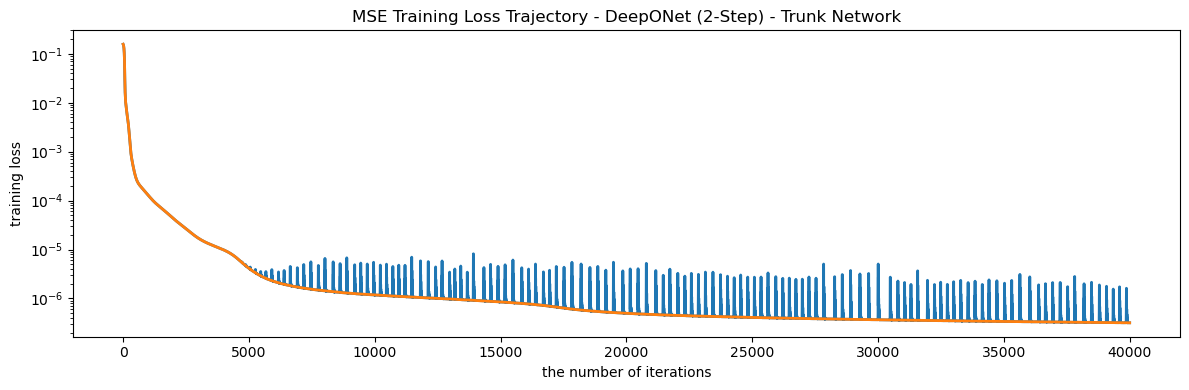

In [26]:

# print(NN_pred_final.shape)
# rel_l2_error = jnp.sqrt(jnp.sum((test_u - NN_pred_final)**2,axis=1) / jnp.sum(test_u**2,axis=1))
# print(f"Avg. MSE error     : {jnp.mean(rel_l2_error):.4e}")



plt.figure(figsize = (12,4))
plt.semilogy(log_loss, linewidth = 2)
plt.semilogy(log_minloss, linewidth =2)
plt.xlabel('the number of iterations')
plt.ylabel('training loss')
plt.title("MSE Training Loss Trajectory - DeepONet (2-Step) - Trunk Network")
plt.tight_layout()
# plt.suptitle(title_str + '\n')
plt.savefig("deeponet_2step_training.png")
plt.show()

In [27]:
for i in [0, 1, 2]:
    res = np.max(np.abs(T_MAT_3d[i] @ la.lstsq(np.array(T_MAT_3d[i]), U_3d[i])[0] - U_3d[i]))
    print(f"t={i} lstsq residual: {res:.4e}")

t=0 lstsq residual: 2.3190e-07
t=1 lstsq residual: 1.5041e-07
t=2 lstsq residual: 3.2037e-07


In [28]:
np.savez('td_loss_hist.npz', log_loss, log_minloss, log_loss_branch, log_minloss_branch, labels = ['log_loss_td', 'log_minloss_td', 'log_loss_branch_td', 'log_minloss_branch_td'])

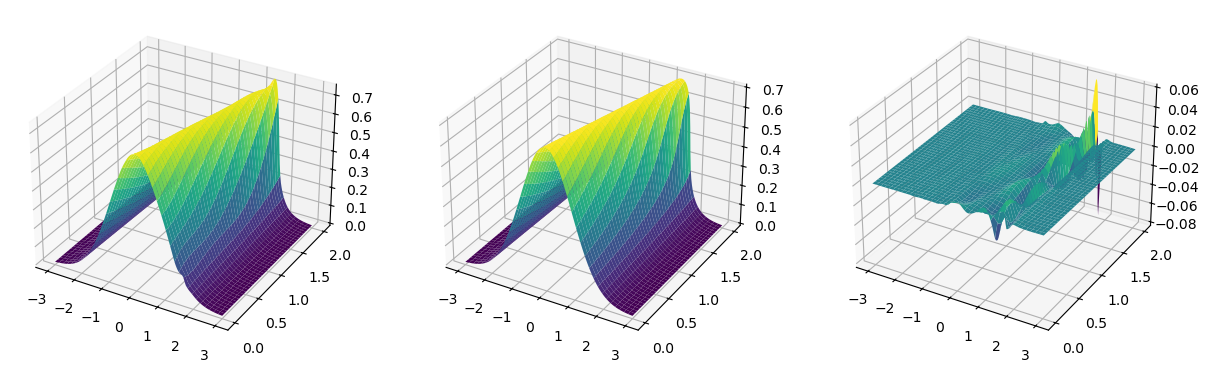

In [29]:
# rescaled RA target

RA_scale_jnp = jnp.array(RA_scale[0, :, 0])  # (K+1,)

def predict_one(u):
    b_tk = vmap(lambda t_val: model_branch(jnp.concatenate([u, jnp.array([t_val])])))(t_grid)  # (T, K+1)
    b_tk = b_tk * RA_scale_jnp  # rescale
    return jnp.einsum("txk,tk->tx", jnp.array(Q_smooth), b_tk)

NN_pred_final = vmap(predict_one)(test_params)  # (N, T, X)

pred  = NN_pred_final[0]          # (T, X)
truth = test_u[0].reshape(len(x_grid), len(t_grid))

T_plot, X_plot = np.meshgrid(t_grid, x_grid, indexing="ij")  # (T, X)
truth = train_u[0].reshape(len(x_grid), len(t_grid)).T  # (T, X)

pred  = NN_pred_final[0]                                    # (T, X)


fig, axes = plt.subplots(1, 3, figsize=(15, 5), subplot_kw=dict(projection='3d'))





x_plot = train_xt[:, 0].reshape(len(x_grid), len(t_grid))
t_plot = train_xt[:, 1].reshape(len(x_grid), len(t_grid))

truth = train_u[0].reshape(len(x_grid), len(t_grid))
pred  = NN_pred_final[0].T  # your pred is (T, X), transpose to (X, T)

axes[0].plot_surface(x_plot, t_plot, pred, cmap="viridis")
axes[1].plot_surface(x_plot, t_plot, truth, cmap="viridis")
axes[2].plot_surface(x_plot, t_plot, pred - truth, cmap="viridis")


In [30]:
print(train_xt[:5])  # is it t-major or x-major?
print(train_u.shape)  # (N, T*X) or (N, X*T)?

[[-3.    0.  ]
 [-2.97  0.  ]
 [-2.94  0.  ]
 [-2.91  0.  ]
 [-2.88  0.  ]]
(25, 40401)


In [31]:
jnp.mean((pred - truth)**2)

Array(1.3817888e-05, dtype=float32)

In [32]:
# loaded_model = load_DeepONet('DeepONet_Diff.eqx')

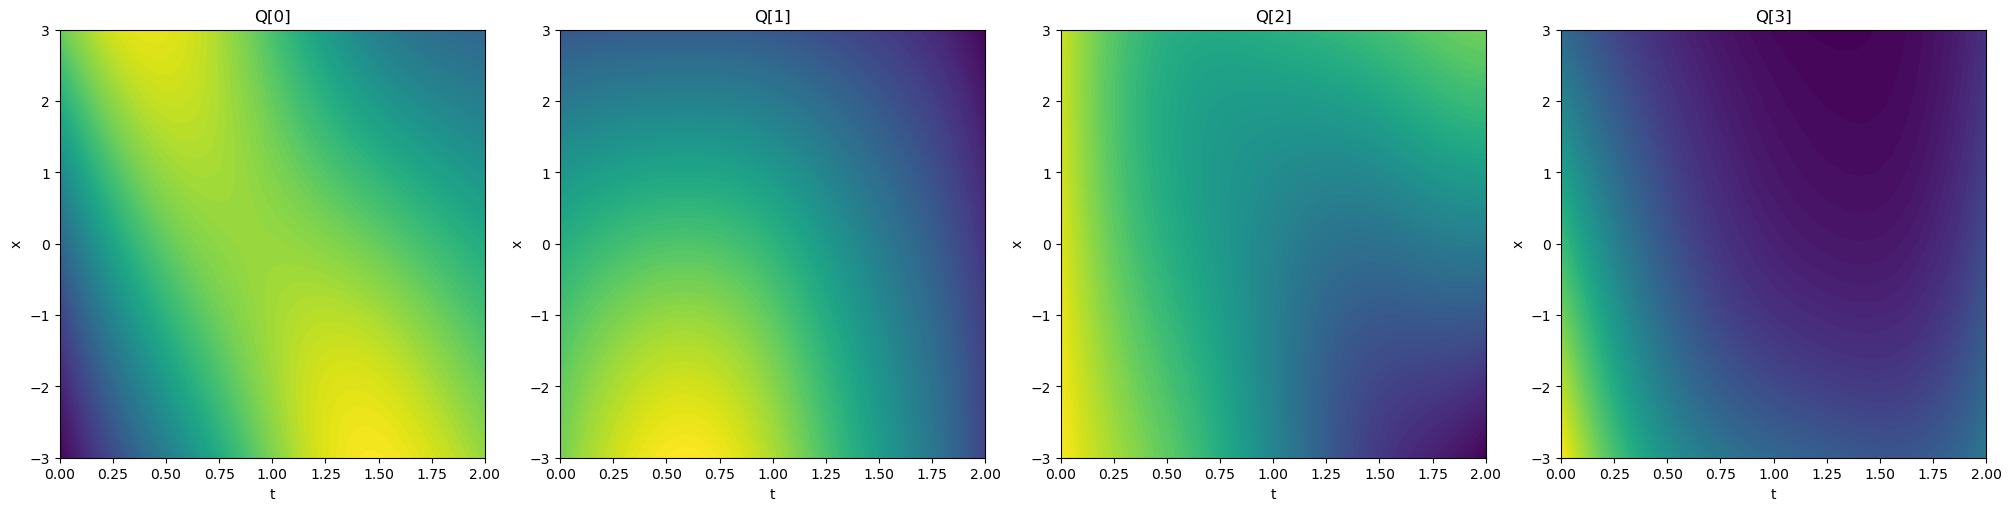

In [33]:
num_bases = 4
ncols = 4
nrows = int(np.ceil(num_bases / ncols))
T, X  = np.meshgrid(t_grid, x_grid, indexing="ij")

trunk_out = np.array(vmap(lambda x: model_trunk(x))(train_xt))  # (T*X, K)
trunk_3d = trunk_out.reshape(len(x_grid), len(t_grid), -1)       # (X, T, K)


fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows), constrained_layout=True)
axes = axes.flatten()

for k, ax in enumerate(axes):
    if k < num_bases:
        b = trunk_3d[:, :, k].T
        im  = ax.contourf(T, X, b, levels=100, cmap='viridis')
        ax.set_title(f"Q[{k}]")
        ax.set_xlabel("t")
        ax.set_ylabel("x")
    else:
        ax.axis("off")

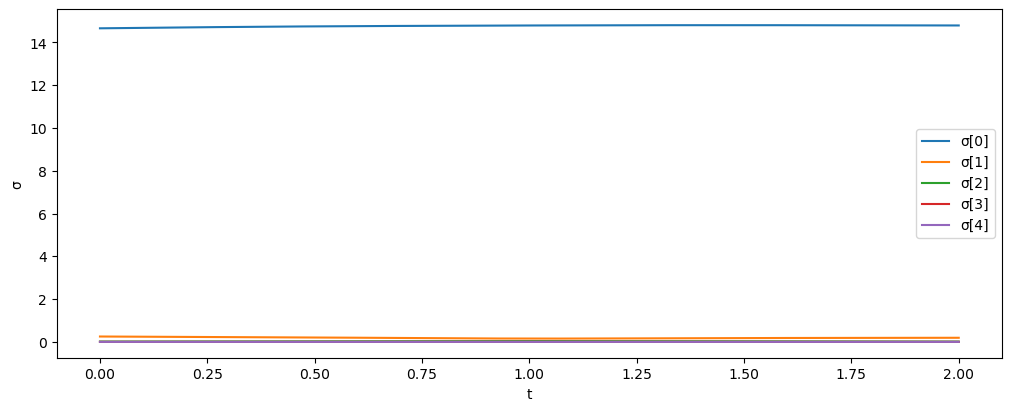

In [34]:
fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)

sv_history = np.zeros((len(t_grid), Q_sign.shape[2]))
for i in range(len(t_grid)):
    _, s, _ = la.svd(np.array(T_MAT_3d[i,:, :]), full_matrices=False)
    sv_history[i] = s

for k in range(Q_sign.shape[2]):
    ax.plot(t_grid, sv_history[:, k], label=f"σ[{k}]")

ax.set_xlabel("t")
ax.set_ylabel("σ")
ax.legend()

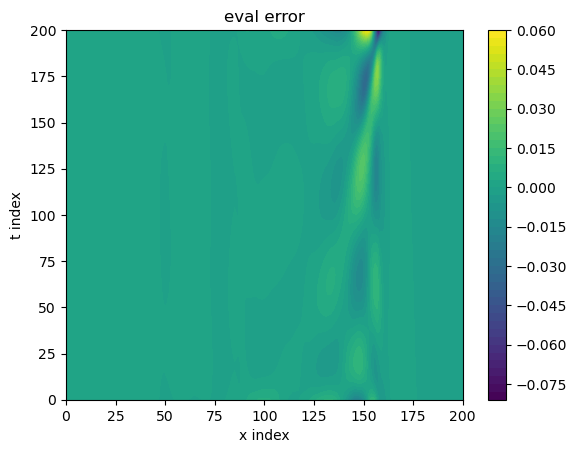

In [35]:
plt.figure()
plt.contourf(pred-truth, levels=50, cmap='viridis')
plt.xlabel('x index')
plt.ylabel('t index')
plt.colorbar()
plt.title('eval error')
plt.show()

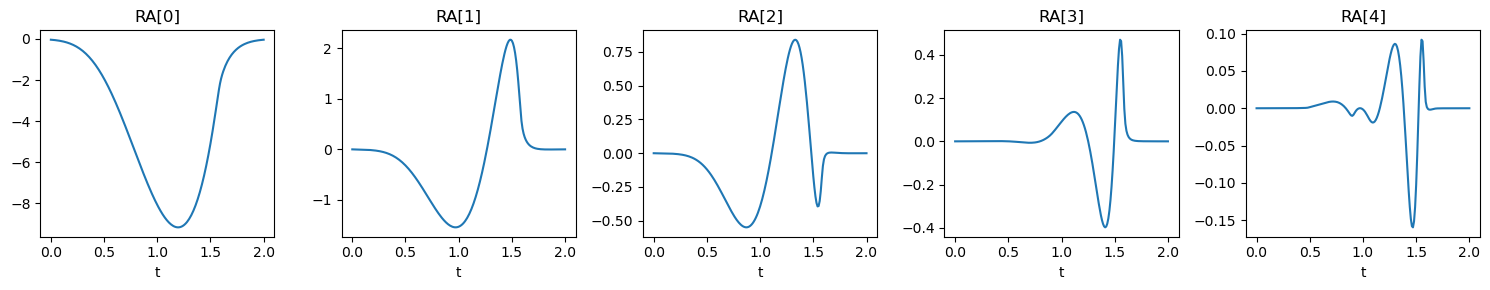

In [36]:
fig, axes = plt.subplots(1, Q_sign.shape[2], figsize=(3 * Q_sign.shape[2], 3))
for k in range(Q_sign.shape[2]):
    axes[k].plot(t_grid, RA_target[:, k, 0])
    axes[k].set_title(f"RA[{k}]")
    axes[k].set_xlabel("t")
plt.tight_layout()
plt.show()

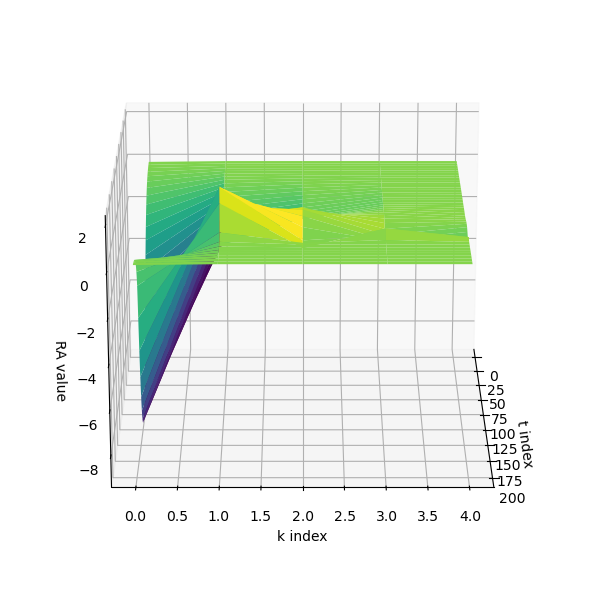

In [37]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
T_idx, K_idx = np.meshgrid(np.arange(RA_target.shape[0]), np.arange(RA_target.shape[1]), indexing='ij')
ax.plot_surface(T_idx, K_idx, RA_target[:, :, 0], cmap='viridis')
ax.set_xlabel('t index')
ax.set_ylabel('k index')
ax.set_zlabel('RA value')
ax.view_init(elev=20, azim=0)
plt.tight_layout()
plt.show()

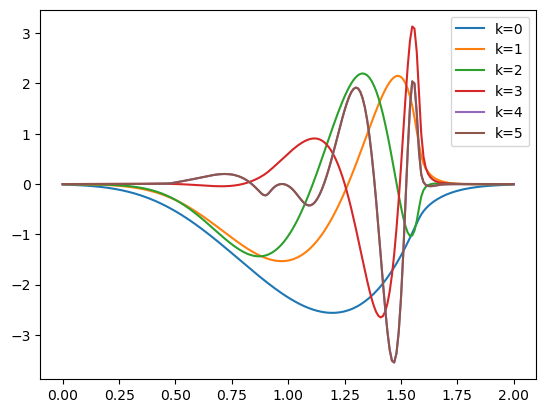

In [38]:
for k in range(6):
    plt.plot(t_grid, RA_target_normed[:, k, 0], label=f"k={k}")
plt.legend(); plt.show()

In [39]:
# find where the spike is
err = np.abs(pred - truth)
t_idx, x_idx = np.unravel_index(np.argmax(err), err.shape)
print(f"spike at t_idx={t_idx}, x_idx={x_idx}")
print(f"t={t_grid[t_idx]:.4f}, x={x_grid[x_idx]:.4f}")

# check Q_sign at that location
print("Q_sign[:,x_idx,:] around spike:")
print(Q_sign[max(0,t_idx-2):t_idx+3, x_idx, :])

# Run this diagnostic before anything else
overlap = Q_sign[t_idx].T @ Q_sign[t_idx - 1]
print(overlap)  # if this is ~I, your correction worked; if not, wrong Q_sign is being used

spike at t_idx=200, x_idx=158
t=2.0000, x=1.7400
Q_sign[:,x_idx,:] around spike:
[[-0.06830928  0.07301319  0.0158864   0.06118174 -0.08081222]
 [-0.06832445  0.07299921  0.01571048  0.06103449 -0.08020067]
 [-0.06833968  0.07298542  0.01553903  0.06089045 -0.07948943]]
[[ 1.0000000e+00 -1.9975012e-04  1.1943985e-05 -1.1388549e-05
   1.4856172e-06]
 [ 1.9985031e-04  9.9999970e-01 -5.2258931e-04  1.3340529e-04
  -3.3627398e-06]
 [-1.1909811e-05  5.2288920e-04  9.9999428e-01 -3.2870176e-03
   1.7131495e-04]
 [ 1.1172015e-05 -1.3170429e-04  3.2868013e-03  9.9999154e-01
   2.3740751e-03]
 [-1.4535162e-06  3.6358547e-06 -1.8086100e-04 -2.3765226e-03
   9.9983239e-01]]


In [40]:
t0 = t_grid[0]
b_pred_t0 = model_branch(jnp.concatenate([test_params[0], jnp.array([t0])]))  # (K+1,)
b_true_t0 = RA_target_normed[0, :, 0]  # (K+1,) for sample 0
print("pred:", b_pred_t0)
print("true:", b_true_t0)
print("diff:", b_pred_t0 - b_true_t0)

pred: [-0.01093168 -0.00191768 -0.00103245  0.00032024 -0.00021797]
true: [-0.01082619 -0.0015786  -0.00076203  0.00022437 -0.00016909]
diff: [-1.0549277e-04 -3.3908454e-04 -2.7041469e-04  9.5865937e-05
 -4.8889240e-05]


In [41]:
print("RA_scale at t=0:", RA_scale[0, :, 0])
print("RA_scale_jnp at t=0:", RA_scale_jnp[0])

RA_scale at t=0: [3.5773773  1.0099082  0.3820366  0.15005194 0.04500183]
RA_scale_jnp at t=0: 3.5773773


In [42]:
for i in range(len(t_grid)):
    print(f"t={i} cond: {np.linalg.cond(T_MAT_3d[i]):.2e}")

t=0 cond: 1.15e+05
t=1 cond: 1.14e+05
t=2 cond: 1.14e+05
t=3 cond: 1.13e+05
t=4 cond: 1.13e+05
t=5 cond: 1.12e+05
t=6 cond: 1.11e+05
t=7 cond: 1.11e+05
t=8 cond: 1.10e+05
t=9 cond: 1.10e+05
t=10 cond: 1.10e+05
t=11 cond: 1.09e+05
t=12 cond: 1.09e+05
t=13 cond: 1.09e+05
t=14 cond: 1.09e+05
t=15 cond: 1.10e+05
t=16 cond: 1.10e+05
t=17 cond: 1.11e+05
t=18 cond: 1.12e+05
t=19 cond: 1.13e+05
t=20 cond: 1.14e+05
t=21 cond: 1.16e+05
t=22 cond: 1.17e+05
t=23 cond: 1.20e+05
t=24 cond: 1.22e+05
t=25 cond: 1.25e+05
t=26 cond: 1.28e+05
t=27 cond: 1.32e+05
t=28 cond: 1.36e+05
t=29 cond: 1.41e+05
t=30 cond: 1.46e+05
t=31 cond: 1.53e+05
t=32 cond: 1.60e+05
t=33 cond: 1.68e+05
t=34 cond: 1.77e+05
t=35 cond: 1.89e+05
t=36 cond: 2.02e+05
t=37 cond: 2.17e+05
t=38 cond: 2.35e+05
t=39 cond: 2.57e+05
t=40 cond: 2.84e+05
t=41 cond: 3.17e+05
t=42 cond: 3.59e+05
t=43 cond: 4.13e+05
t=44 cond: 4.85e+05
t=45 cond: 5.82e+05
t=46 cond: 7.16e+05
t=47 cond: 8.94e+05
t=48 cond: 1.09e+06
t=49 cond: 1.17e+06
t=50 cond:

In [43]:
overlap = Q_smooth[0].T @ Q_smooth[1]
print(np.diag(overlap))  # if any entry is negative or far from 1, that's your spike

[0.9999995 1.        1.0000005 0.9999958 0.9999424]


In [44]:
print(sv_history[0])  # singular values at t=0
print(sv_history[1])

[1.46593962e+01 2.51312196e-01 1.62729602e-02 1.48899946e-03
 1.27512074e-04]
[1.46616335e+01 2.50452518e-01 1.62864514e-02 1.55131973e-03
 1.28236075e-04]
